# 02. Геометрия и базовая xG-модель

Ноутбук проверяет геометрию на известных случаях и показывает,
как далеко можно уехать на двух признаках: расстоянии и угле.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

In [2]:
from xg_context.config import FEATURE_SETS, PROCESSED_DATA_DIR, RANDOM_SEED, TABLES_DIR
from xg_context.evaluation import calibration_table, evaluate_predictions
from xg_context.geometry import goal_mouth_angle, shot_distance
from xg_context.models import build_model, predict_proba
from xg_context.preprocessing import select_features
from xg_context.splitting import load_split
from xg_context.visualization import apply_style, plot_calibration

apply_style()
shots = pd.read_parquet(PROCESSED_DATA_DIR / 'context_eligible_shots.parquet')

## Геометрия на известных случаях

Точка пенальти — (108, 40): расстояние 12 ярдов, ворота видны под
углом `2·arctan(4/12) ≈ 36.87°`. Это же проверяется в `tests/test_geometry.py`.

In [3]:
penalty_spot = (108.0, 40.0)
print('расстояние:', float(shot_distance(*penalty_spot)))
print('угол, градусы:', float(goal_mouth_angle(*penalty_spot, degrees=True)))
print('ожидаемый угол:', 2 * np.degrees(np.arctan2(4, 12)))

расстояние: 12.0
угол, градусы: 36.86989764584402
ожидаемый угол: 36.86989764584402


## Разбиение

Разбиение зафиксировано скриптом `run_experiments.py` и читается с диска,
чтобы ноутбук не мог случайно создать другое.

In [4]:
split = load_split(PROCESSED_DATA_DIR / 'split.json')
assignment = {
    match_id: name
    for name, ids in split['match_ids'].items()
    for match_id in ids
}
shots['split'] = shots['match_id'].map(assignment)
train = shots[shots['split'] == 'train']
test = shots[shots['split'] == 'test']
pd.read_csv(TABLES_DIR / 'split_summary.csv')

,split,n_matches,n_shots,share_of_shots,n_goals,goal_rate,share_Serie A,share_Premier League,share_La Liga,share_Ligue 1
0,train,1067,26206,0.699069,2499,0.095360,0.263451,0.261772,0.242235,0.232542
1,validation,226,5642,0.150506,534,0.094647,0.263559,0.262141,0.241227,0.233073
2,test,224,5639,0.150425,535,0.094875,0.263522,0.262103,0.241355,0.233020


Матчи не пересекаются между частями, доли лиг и доля голов совпадают
с точностью до долей процента.

## M0 и M1: базовая частота и чистая геометрия

In [5]:
results = {}
for name, feature_set in [('M0: базовая частота', 'geometry'), ('M1: геометрия', 'geometry')]:
    model_name = 'dummy' if name.startswith('M0') else 'logistic'
    features = FEATURE_SETS[feature_set]
    model = build_model(model_name, features, seed=RANDOM_SEED)
    model.fit(select_features(train, features), train['is_goal'])
    probabilities = predict_proba(model, select_features(test, features))
    results[name] = evaluate_predictions(test['is_goal'], probabilities)

pd.DataFrame(results).T[['log_loss', 'brier', 'roc_auc', 'pr_auc']].round(5)

,log_loss,brier,roc_auc,pr_auc
M0: базовая частота,0.31368,0.08587,0.50000,0.09487
M1: геометрия,0.27282,0.07700,0.75961,0.29818


Две геометрические переменные уже дают заметный отрыв от базовой частоты.
Дальше вопрос в том, сколько ещё информации добавляет контекст момента.

## Калибровка M1

In [6]:
features = FEATURE_SETS['geometry']
model = build_model('logistic', features, seed=RANDOM_SEED)
model.fit(select_features(train, features), train['is_goal'])
probabilities = predict_proba(model, select_features(test, features))
table = calibration_table(test['is_goal'], probabilities, n_bins=10)
table.round(4)

,bin,lower,upper,n,mean_predicted,observed_rate,n_goals,gap
0,0,0.0002,0.0251,564,0.0186,0.0142,8,-0.0044
1,1,0.0251,0.0330,564,0.0290,0.0177,10,-0.0113
2,2,0.0330,0.0412,564,0.0370,0.0301,17,-0.0069
3,3,0.0412,0.0516,564,0.0462,0.0319,18,-0.0143
4,4,0.0516,0.0646,563,0.0577,0.0515,29,-0.0062
5,5,0.0646,0.0828,563,0.0731,0.0799,45,0.0068
6,6,0.0828,0.1092,565,0.0946,0.1310,74,0.0364
7,7,0.1092,0.1465,564,0.1267,0.1330,75,0.0063
8,8,0.1465,0.2047,564,0.1717,0.1667,94,-0.0051
9,9,0.2047,0.8694,564,0.2976,0.2926,165,-0.0050


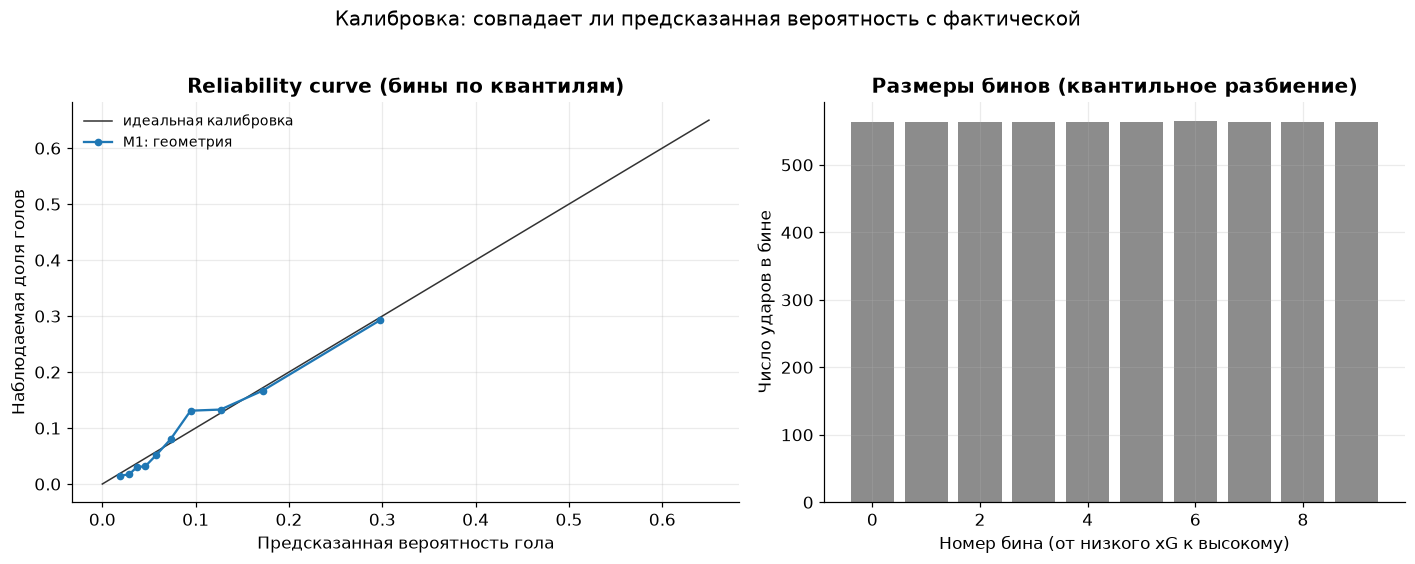

In [7]:
plot_calibration({'M1: геометрия': table});

Модель по геометрии уже неплохо откалибрована: точки лежат близко
к диагонали. Проблема не в смещении вероятностей, а в различающей
способности — она и должна вырасти от контекста.